# Import Modules

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math
from torch.utils.tensorboard import SummaryWriter
import json
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from sklearn.manifold import spectral_embedding
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import rbf_kernel

## Import Dataset Class

In [2]:
from dataset_classes import ISO_NE

## Import Models

In [3]:
from models_with_temporal_graph import (
    GLFN_TC_Attention, GLFN_TC_GlobalLocal,
    GLFN_TC_Linear, GLFN_TC_MultiScale,
)

## Import Training and Testing Loops

In [4]:
from helper_functions_trial import train_model, test_model

## Sensitivity Setup and Config

In [5]:
# ============================================================
# SENSITIVITY ANALYSIS — Setup & Configuration
# ============================================================
import time, os, traceback
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler

# ── 0. Reproducibility & Baseline ────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Paper test MSE = 0.2167. Validation is usually ~5-10% lower.
BASELINE_VAL_LOSS = 0.205

# ▶ Which model variant to run sensitivity on
SENSITIVITY_MODEL_CLS = GLFN_TC_MultiScale

SAVE_DIR = "Sensitivity_Analysis"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"✅ Save directory: {SAVE_DIR}")

✅ Save directory: Sensitivity_Analysis


## Dataset & Dataloader Setup

In [6]:
# ============================================================
# SENSITIVITY — Dataset Preparation (identical to baseline)
# ============================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Device: {device}")

dataset = ISO_NE(
    csv_path="selected_data_ISONE.csv",
    T_in=72, T_out=240,
    lag_hours=[1, 24],
    rolling_windows=[24],
)

total_len   = len(dataset.df_numeric)
train_split = int(0.6 * total_len)
val_split   = int(0.8 * total_len)

scaler = StandardScaler()
scaler.fit(dataset.df_numeric.iloc[:train_split].values.astype(np.float32))
dataset.apply_scaler(scaler)
dataset.scaler = scaler

effective_len = len(dataset)
train_end = min(train_split - dataset.T_in - dataset.T_out, effective_len)
val_end   = min(val_split   - dataset.T_in - dataset.T_out, effective_len)

BATCH_SIZE = 32
train_loader = DataLoader(Subset(dataset, range(0, train_end)),       batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(Subset(dataset, range(train_end, val_end)), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(Subset(dataset, range(val_end, effective_len)), batch_size=BATCH_SIZE, shuffle=False)

print(f"📊 Train: {train_end} | Val: {val_end - train_end} | Test: {effective_len - val_end}")

🖥️  Device: cuda
Loaded dataset with 16 features (target=demand), total rows=103752
📊 Train: 61939 | Val: 20750 | Test: 20751


## Hyperparameters & 13 Sensitivity Configs

In [7]:
# ============================================================
# SENSITIVITY — Shared Hparams + 13 Config Variants
# ============================================================
BASE_HPARAMS = dict(
    N=dataset.N, T_in=72, T_out=240, d=32,
    dropout_gcn=0.2, dropout_temporal=0.2,
    lr=1e-3,
    scheduler_patience=3, weight_decay=1e-4,
    epochs=100,
    GCN_Layer=5, hidden_dim=64, kernel_size=7, dilation=3,
    lambda_smooth=0.01,
    lambda_sparse=1e-4,
)

# 13 non-baseline variants (cleaned trailing spaces for safety)
sensitivity_configs = {
    # 1. GCN Depth
    "gcn_depth_1": {"GCN_Layer": 1,  "hidden_dim":  64,  "kernel_size":  7,  "dilation": 3},
    "gcn_depth_2": {"GCN_Layer": 2,  "hidden_dim":  64,  "kernel_size":  7,  "dilation": 3},
    "gcn_depth_3": {"GCN_Layer": 3,  "hidden_dim":  64,  "kernel_size":  7,  "dilation": 3},
    "gcn_depth_7": {"GCN_Layer": 7,  "hidden_dim":  64,  "kernel_size":  7,  "dilation": 3},
    # 2. Hidden Size
    "hidden_32":   {"GCN_Layer": 5,  "hidden_dim":  32,  "kernel_size":  7,  "dilation": 3},
    "hidden_128":  {"GCN_Layer": 5,  "hidden_dim": 128,  "kernel_size":  7,  "dilation": 3},
    "hidden_256":  {"GCN_Layer": 5,  "hidden_dim": 256,  "kernel_size":  7,  "dilation": 3},
    # 3. Kernel Size
    "kernel_3":    {"GCN_Layer": 5,  "hidden_dim":  64,  "kernel_size":  3,  "dilation": 3},
    "kernel_5":    {"GCN_Layer": 5,  "hidden_dim":  64,  "kernel_size":  5,  "dilation": 3},
    "kernel_11":   {"GCN_Layer": 5,  "hidden_dim":  64,  "kernel_size": 11,  "dilation": 3},
    # 4. Dilation Factor
    "dilation_1":  {"GCN_Layer": 5,  "hidden_dim":  64,  "kernel_size":  7,  "dilation": 1},
    "dilation_2":  {"GCN_Layer": 5,  "hidden_dim":  64,  "kernel_size":  7,  "dilation": 2},
    "dilation_5":  {"GCN_Layer": 5,  "hidden_dim":  64,  "kernel_size":  7,  "dilation": 5},
}

print(f"🧪 Loaded {len(sensitivity_configs)} sensitivity configs.")

🧪 Loaded 13 sensitivity configs.


## Training Helper Function

In [8]:
# ============================================================
# SENSITIVITY — Training Loop Helper
# ============================================================
import torch.nn as nn

def _sensitivity_train(model, train_loader, val_loader, device,
                       epochs, lr, weight_decay, scheduler_patience, save_path,
                       lambda_smooth=0.01, lambda_sparse=1e-4):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=scheduler_patience, factor=0.5
    )
    best_val   = float("inf")
    patience_c = 0
    EARLY_STOP = 15
    train_losses, val_losses, epoch_times = [], [], []
    peak_mem_mb = 0.0

    if device == "cuda":
        torch.cuda.reset_peak_memory_stats(device)

    for epoch in range(1, epochs + 1):
        # ── Train ──
        model.train()
        t0 = time.perf_counter()
        run_loss = 0.0

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]", leave=False)
        for X, Y in train_pbar:
            X, Y = X.to(device), Y.to(device)
            optimizer.zero_grad()

            # UNPACK A to apply graph regularization (parity with main pipeline)
            pred, A = model(X)

            # 1. Task loss
            mse_loss = criterion(pred, Y)

            # 2. Temporal consistency: L2 penalty between adjacent batch graphs
            smooth_loss = nn.functional.mse_loss(A[:-1], A[1:].detach()) if A.size(0) > 1 else torch.tensor(0.0, device=device)

            # 3. Sparsity: L1 penalty to keep learned graph sparse
            sparse_loss = torch.norm(A, p=1)

            # Combined loss
            loss = mse_loss + lambda_smooth * smooth_loss + lambda_sparse * sparse_loss

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            run_loss += loss.item()
            train_pbar.set_postfix(loss=loss.item(), smooth=f"{smooth_loss.item():.4f}")

        epoch_times.append(time.perf_counter() - t0)
        train_losses.append(run_loss / len(train_loader))

        # ── Validate ──
        model.eval()
        vl = 0.0
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [Val]   ", leave=False)
        with torch.no_grad():
            for X, Y in val_pbar:
                X, Y = X.to(device), Y.to(device)
                pred, _ = model(X)
                vl += criterion(pred, Y).item()
        vl /= len(val_loader)
        val_losses.append(vl)
        scheduler.step(vl)

        # ── GPU Memory ──
        if device == "cuda":
            peak_mem_mb = max(peak_mem_mb, torch.cuda.max_memory_allocated(device) / 1024**2)

        # ── Checkpoint ──
        if vl < best_val:
            best_val = vl
            torch.save({"epoch": epoch, "model_state_dict": model.state_dict(), "val_loss": best_val}, save_path)
            patience_c = 0
        else:
            patience_c += 1
            if patience_c >= EARLY_STOP:
                print(f"    ⏹ Early stop @ epoch {epoch}")
                break

        if epoch % 10 == 0 or epoch == 1:
            print(f"    Epoch {epoch:03d} | Train {train_losses[-1]:.4f}  "
                  f"| Val {vl:.4f} | {epoch_times[-1]:.1f}s | Best {best_val:.4f} ")

    return dict(
        best_val_loss=best_val,
        train_losses=train_losses,
        val_losses=val_losses,
        avg_epoch_time_s=float(np.mean(epoch_times)),
        peak_gpu_mem_mb=peak_mem_mb,
    )

## Inference & Metrics Helper Function

In [9]:
# ============================================================
# SENSITIVITY — Inference Timing & Test Metrics Helper
# ============================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def _sensitivity_infer(model, test_loader, device):
    model.eval()
    batch_times, preds_all, trues_all = [], [], []
    with torch.no_grad():
        for X, Y in test_loader:
            X, Y = X.to(device), Y.to(device)
            if device == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            pred, _ = model(X)
            if device == "cuda":
                torch.cuda.synchronize()
            batch_times.append(time.perf_counter() - t0)
            preds_all.append(pred.cpu().numpy())
            trues_all.append(Y.cpu().numpy())

    preds_flat = np.concatenate(preds_all).flatten()
    trues_flat = np.concatenate(trues_all).flatten()

    n          = len(preds_flat)
    n_features = len(dataset.feature_names)
    target_col = dataset.target_idx   # 0 = demand

    dummy_preds = np.zeros((n, n_features))
    dummy_trues = np.zeros((n, n_features))
    dummy_preds[:, target_col] = preds_flat
    dummy_trues[:, target_col] = trues_flat

    preds_unscaled = dataset.scaler.inverse_transform(dummy_preds)[:, target_col]
    trues_unscaled = dataset.scaler.inverse_transform(dummy_trues)[:, target_col]

    return dict(
        avg_inference_ms = float(np.mean(batch_times)) * 1000,
        test_mse = float(mean_squared_error(trues_unscaled, preds_unscaled)),
        test_mae = float(mean_absolute_error(trues_unscaled, preds_unscaled)),
        test_r2  = float(r2_score(trues_unscaled, preds_unscaled)),
    )

## Main Sensitivity Loop (13 Runs)

In [10]:
# ============================================================
# SENSITIVITY — Automated Training Loop (13 configs)
# ============================================================
all_results = {}
n_total = len(sensitivity_configs)

for run_idx, (cfg_name, cfg_overrides) in enumerate(sensitivity_configs.items(), 1):
    print(f"\n{'='*64}")
    print(f"[{run_idx}/{n_total}]  {cfg_name}  |  {cfg_overrides}")
    print(f"{'='*64}")

    hp = {**BASE_HPARAMS, **cfg_overrides}

    model = SENSITIVITY_MODEL_CLS(
        N=hp["N"], T_in=hp["T_in"], T_out=hp["T_out"], d=hp["d"],
        hidden_dim=hp["hidden_dim"], GCN_Layer=hp["GCN_Layer"],
        dropout_gcn=hp["dropout_gcn"], dropout_temporal=hp["dropout_temporal"],
        kernel_size=hp["kernel_size"], dilation=hp["dilation"],
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  🧠 Trainable params: {n_params:,} ")

    save_path = os.path.join(SAVE_DIR, f"{cfg_name}_best_model.pth")

    try:
        # Pass regularization weights for exact parity with helper_functions_trial.py
        train_info = _sensitivity_train(
            model, train_loader, val_loader, device,
            epochs=hp["epochs"], lr=hp["lr"],
            weight_decay=hp["weight_decay"],
            scheduler_patience=hp["scheduler_patience"],
            save_path=save_path,
            lambda_smooth=hp.get("lambda_smooth", 0.01),
            lambda_sparse=hp.get("lambda_sparse", 1e-4)
        )

        ckpt = torch.load(save_path, map_location="cpu")
        ckpt["hparams"]  = hp
        ckpt["cfg_name"] = cfg_name
        ckpt["n_params"] = n_params
        torch.save(ckpt, save_path)

        model.load_state_dict(ckpt["model_state_dict"])
        model.to(device)
        infer_info = _sensitivity_infer(model, test_loader, device)

        beats = train_info["best_val_loss"] < BASELINE_VAL_LOSS
        if not beats and os.path.exists(save_path):
            os.remove(save_path)
            saved_path = "— (did not beat baseline)"
        else:
            saved_path = save_path

        all_results[cfg_name] = dict(
            status="OK",
            **cfg_overrides,
            n_params=n_params,
            best_val_loss=train_info["best_val_loss"],
            avg_epoch_time_s=train_info["avg_epoch_time_s"],
            peak_gpu_mem_mb=train_info["peak_gpu_mem_mb"],
            avg_inference_ms=infer_info["avg_inference_ms"],
            test_mse=infer_info["test_mse"],
            test_mae=infer_info["test_mae"],
            test_r2=infer_info["test_r2"],
            beats_baseline=beats,
            model_path=saved_path,
            train_losses=train_info["train_losses"],
            val_losses=train_info["val_losses"],
        )

        flag = "✅ BEATS BASELINE" if beats else "❌ below baseline"
        print(f"\n  → Val {train_info['best_val_loss']:.4f} | MSE {infer_info['test_mse']:.4f}  "
              f"| {train_info['avg_epoch_time_s']:.1f}s/ep  "
              f"| {infer_info['avg_inference_ms']:.1f}ms/batch  "
              f"| {train_info['peak_gpu_mem_mb']:.0f}MB GPU  {flag}")

    except Exception as exc:
        print(f"  ❌ FAILED: {exc}")
        traceback.print_exc()
        all_results[cfg_name] = dict(status="FAILED", error=str(exc), **cfg_overrides)

print(f"\n\n🏁 All {n_total} sensitivity runs complete.")


[1/13]  gcn_depth_1  |  {'GCN_Layer': 1, 'hidden_dim': 64, 'kernel_size': 7, 'dilation': 3}
  🧠 Trainable params: 686,112 


    Epoch 001 | Train 0.3064  | Val 0.2888 | 23.0s | Best 0.2888 


    Epoch 010 | Train 0.2488  | Val 0.2221 | 23.4s | Best 0.2221 


    Epoch 020 | Train 0.2273  | Val 0.2022 | 24.0s | Best 0.1995 


    Epoch 030 | Train 0.2204  | Val 0.2003 | 24.0s | Best 0.1945 


...

    Epoch 010 | Train 0.2612  | Val 0.2678 | 27.0s | Best 0.2678 


    Epoch 020 | Train 0.2541  | Val 0.2469 | 26.4s | Best 0.2434 


    Epoch 030 | Train 0.2296  | Val 0.1996 | 26.4s | Best 0.1996 


    Epoch 040 | Train 0.2163  | Val 0.2021 | 27.0s | Best 0.1964 


    ⏹ Early stop @ epoch 47

  → Val 0.1964 | MSE 1442845.9439  | 26.3s/ep  | 2.9ms/batch  | 57MB GPU  ✅ BEATS BASELINE


🏁 All 13 sensitivity runs complete.


## Build Summary DataFrame & Print

In [27]:
# ============================================================
# SENSITIVITY — Summary DataFrame
# ============================================================
BASELINE_ROW = dict(
    config="baseline_estimated (GCN=5 | h=64 | k=7 | d=3)",
    GCN_Layer=5,
    hidden_dim=64,
    kernel_size=7,
    dilation=3,

    n_params=None,

    #derived estimate norm val loss (--5%)
    best_val_loss=BASELINE_VAL_LOSS,

    #unknown
    avg_epoch_time_s=None,
    peak_gpu_mem_mb=None,
    avg_inference_ms=None,

    #from paper
    test_mse=0.2167,
    test_mae=0.2889,
    test_r2=0.8204,

    beats_baseline=False,

    model_path="Paper_Runs/TR_GNN_ISO_NE_Multi_Scale_best_model.pth",

    status="BASELINE_ESTIMATED",
)

rows = [BASELINE_ROW]
for cfg_name, r in all_results.items():
    base = dict(config=cfg_name, **{k: r.get(k) for k in
                ["GCN_Layer","hidden_dim","kernel_size","dilation","n_params",
                 "best_val_loss","avg_epoch_time_s","peak_gpu_mem_mb",
                 "avg_inference_ms","test_mse","test_mae","test_r2",
                 "beats_baseline","model_path","status"]})
    rows.append(base)

df_results = pd.DataFrame(rows)
print(df_results[["config","best_val_loss","test_mse","test_mae","test_r2",
                   "avg_epoch_time_s","avg_inference_ms","peak_gpu_mem_mb",
                   "beats_baseline"]].to_string(index=False))

                                       config  best_val_loss     test_mse   test_mae  test_r2  avg_epoch_time_s  avg_inference_ms  peak_gpu_mem_mb  beats_baseline
baseline_estimated (GCN=5 | h=64 | k=7 | d=3)       0.205000 2.167000e-01   0.288900 0.820400               NaN               NaN              NaN           False
                                  gcn_depth_1       0.184458 1.389498e+06 843.881874 0.819473         23.821686          2.610193        45.807617            True
                                  gcn_depth_2       0.184131 1.382074e+06 835.776352 0.820438         25.097813          2.628227        56.516113            True
                                  gcn_depth_3       0.195101 1.446766e+06 863.541196 0.812033         24.669591          2.746066        56.564453            True
                                  gcn_depth_7       0.191924 1.412666e+06 836.416300 0.816463         27.708028          3.156739        56.757812            True
                      

## Excel Export (Summary + Loss Data)

In [28]:
import openpyxl

In [29]:
# ============================================================
# SENSITIVITY — Excel Report Export
# ============================================================
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.formatting.rule import ColorScaleRule

COLS = [
    ("Config", "config"), ("GCN Layers", "GCN_Layer"), ("Hidden Dim", "hidden_dim"),
    ("Kernel Size", "kernel_size"), ("Dilation", "dilation"), ("# Params", "n_params"),
    ("Best Val Loss", "best_val_loss"), ("Test MSE", "test_mse"), ("Test MAE", "test_mae"),
    ("Test R²", "test_r2"), ("Avg Epoch Time (s)", "avg_epoch_time_s"),
    ("Infer. ms/batch", "avg_inference_ms"), ("Peak GPU Mem (MB)", "peak_gpu_mem_mb"),
    ("Beats Baseline?", "beats_baseline"), ("Model Path", "model_path"), ("Status", "status"),
]

def _hdr(ws, row, col, value):
    c = ws.cell(row=row, column=col, value=value)
    c.font = Font(bold=True, color="FFFFFF", size=11)
    c.fill = PatternFill("solid", fgColor="1F4E79")
    c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    c.border = Border(left=Side("thin","AAAAAA"), right=Side("thin","AAAAAA"),
                      top=Side("thin","AAAAAA"), bottom=Side("thin","AAAAAA"))
    return c

FILL_BASELINE = PatternFill("solid", fgColor="BDD7EE")
FILL_WIN      = PatternFill("solid", fgColor="C6EFCE")
FILL_FAIL     = PatternFill("solid", fgColor="FFC7CE")
FILL_NORM     = PatternFill("solid", fgColor="F9F9F9")

wb = openpyxl.Workbook()

# ── Sheet 1: Summary ──
ws1 = wb.active
ws1.title = "Sensitivity Results"
ws1.row_dimensions[1].height = 32
for col_i, (hdr, _) in enumerate(COLS, 1):
    _hdr(ws1, 1, col_i, hdr)

for row_i, row_data in enumerate(rows, 2):
    status = row_data.get("status", "")
    is_base = status == "BASELINE"
    is_fail = status == "FAILED"
    is_win  = row_data.get("beats_baseline", False)
    fill = FILL_BASELINE if is_base else FILL_WIN if is_win else FILL_FAIL if is_fail else FILL_NORM
    for col_i, (_, key) in enumerate(COLS, 1):
        val = row_data.get(key)
        c = ws1.cell(row=row_i, column=col_i, value=val)
        c.border = Border(left=Side("thin","AAAAAA"), right=Side("thin","AAAAAA"),
                          top=Side("thin","AAAAAA"), bottom=Side("thin","AAAAAA"))
        c.alignment = Alignment(horizontal="center", vertical="center")
        c.fill = fill
        if isinstance(val, float):
            c.number_format = "0.0000"

for col_i in range(1, len(COLS) + 1):
    max_w = max(len(str(ws1.cell(r, col_i).value or "")) for r in range(1, len(rows) + 2))
    ws1.column_dimensions[get_column_letter(col_i)].width = min(max_w + 3, 32)

val_col_letter = get_column_letter([k for _, k in COLS].index("best_val_loss") + 1)
ws1.conditional_formatting.add(
    f"{val_col_letter}2:{val_col_letter}{len(rows)+1}",
    ColorScaleRule(start_type="min", start_color="63BE7B", end_type="max", end_color="F8696B"),
)

# ── Sheet 2: Loss Curves Data ──
ws2 = wb.create_sheet("Loss Curves Data")
ok_cfgs = {k: v for k, v in all_results.items() if v.get("status") == "OK"}
max_ep = max((len(v["train_losses"]) for v in ok_cfgs.values()), default=0)

flat_hdrs = ["Epoch"]
for k in ok_cfgs:
    flat_hdrs += [f"{k}_train", f"{k}_val"]
for ci, h in enumerate(flat_hdrs, 1):
    _hdr(ws2, 1, ci, h)

for ep in range(max_ep):
    ws2.cell(row=ep+2, column=1, value=ep+1)
    ci = 2
    for r in ok_cfgs.values():
        tl = r.get("train_losses", [])
        vl = r.get("val_losses", [])
        ws2.cell(row=ep+2, column=ci,   value=tl[ep] if ep < len(tl) else None)
        ws2.cell(row=ep+2, column=ci+1, value=vl[ep] if ep < len(vl) else None)
        ci += 2

excel_path = os.path.join(SAVE_DIR, "sensitivity_analysis_results.xlsx")
wb.save(excel_path)
print(f"✅ Excel saved → {excel_path}")

✅ Excel saved → Sensitivity_Analysis\sensitivity_analysis_results.xlsx


## Loss Curve Figures (4 Groups)

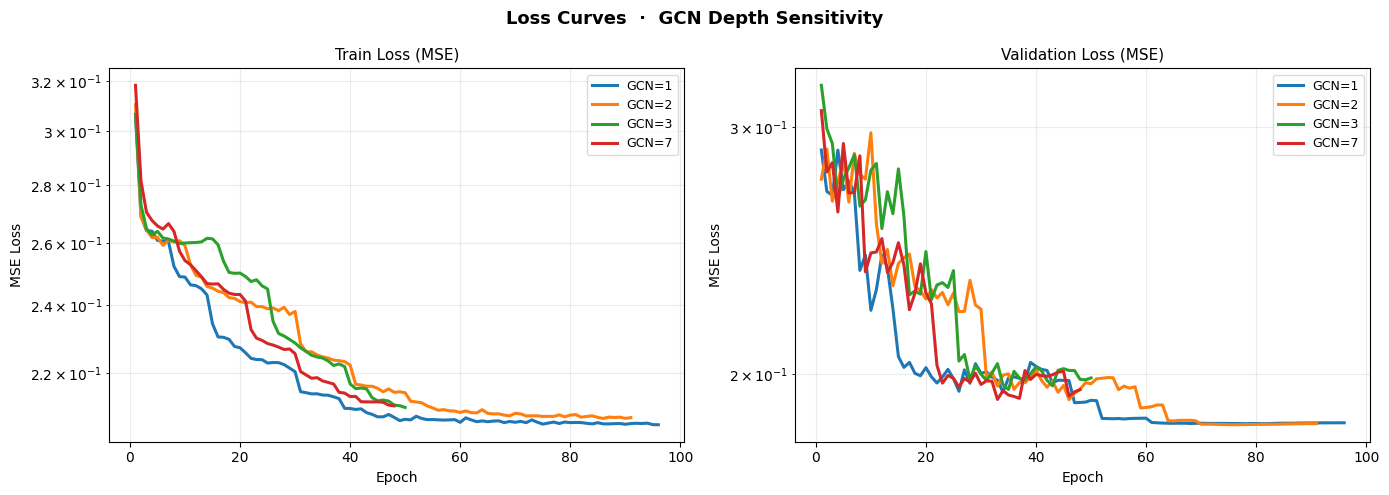

  📉 Saved: loss_curves_gcn_depth.png


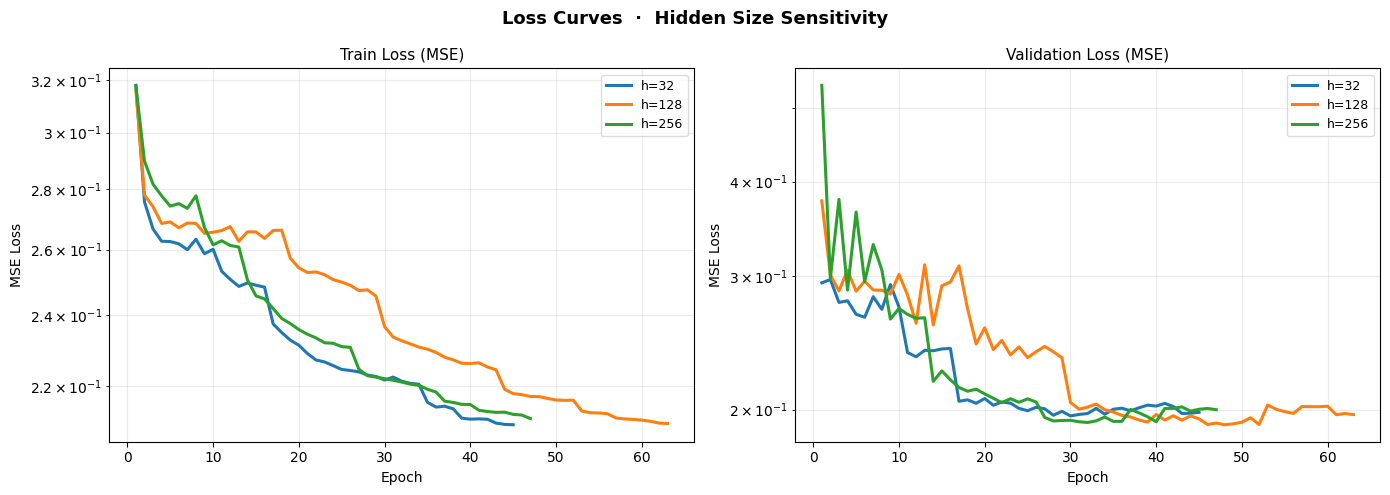

  📉 Saved: loss_curves_hidden_size.png


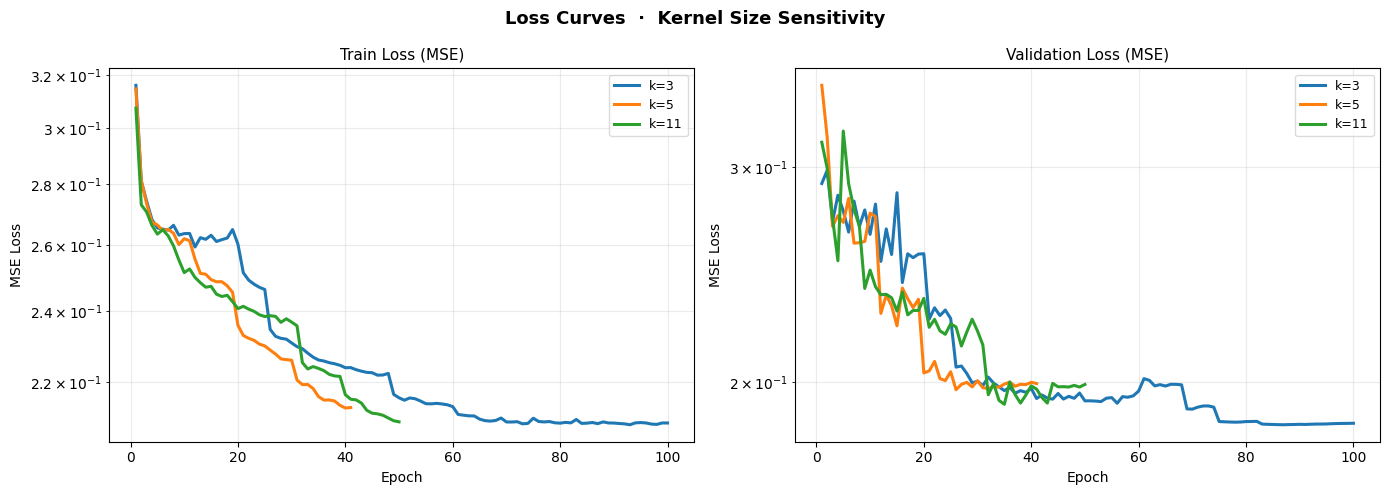

  📉 Saved: loss_curves_kernel_size.png


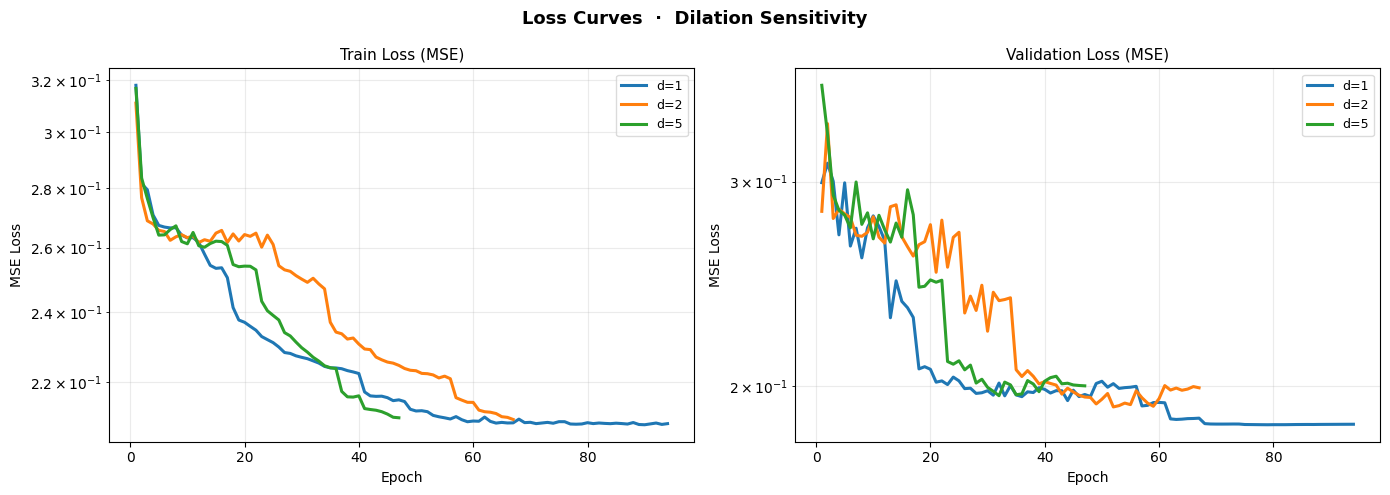

  📉 Saved: loss_curves_dilation.png


In [30]:
# ============================================================
# SENSITIVITY — Loss Curve Plots (one per sensitivity group)
# ============================================================
fig_dir = os.path.join(SAVE_DIR, "loss_curves")
os.makedirs(fig_dir, exist_ok=True)
GROUP_COLORS = plt.cm.tab10.colors

groups = {
    "GCN Depth":   {"gcn_depth_1": "GCN=1", "gcn_depth_2": "GCN=2",
                    "gcn_depth_3": "GCN=3", "gcn_depth_7": "GCN=7"},
    "Hidden Size": {"hidden_32": "h=32", "hidden_128": "h=128", "hidden_256": "h=256"},
    "Kernel Size": {"kernel_3": "k=3",  "kernel_5": "k=5",    "kernel_11": "k=11"},
    "Dilation":    {"dilation_1": "d=1","dilation_2": "d=2",  "dilation_5": "d=5"},
}

for group_name, cfg_label_map in groups.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    fig.suptitle(f"Loss Curves  ·  {group_name} Sensitivity", fontsize=13, fontweight="bold")

    for ax, loss_key, panel_title in zip(axes, ["train_losses", "val_losses"],
                                         ["Train Loss (MSE)", "Validation Loss (MSE)"]):
        for ci, (cfg_name, label) in enumerate(cfg_label_map.items()):
            r = ok_cfgs.get(cfg_name)
            if r is None: continue
            curve = r.get(loss_key, [])
            lw = 2.2 if r.get("beats_baseline") else 1.5
            ls = "-" if r.get("beats_baseline") else "--"
            ax.plot(range(1, len(curve)+1), curve,
                    color=GROUP_COLORS[ci % len(GROUP_COLORS)],
                    linewidth=lw, linestyle=ls, label=label)

        ax.set_xlabel("Epoch", fontsize=10)
        ax.set_ylabel("MSE Loss", fontsize=10)
        ax.set_title(panel_title, fontsize=11)
        ax.set_yscale("log")
        ax.legend(fontsize=9, framealpha=0.7)
        ax.grid(True, which="both", alpha=0.25)

    plt.tight_layout()
    fname = f"loss_curves_{group_name.replace(' ','_').lower()}.png"
    fig.savefig(os.path.join(fig_dir, fname), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  📉 Saved: {fname}")

## Summary Bar + Efficiency Scatter + Final Report

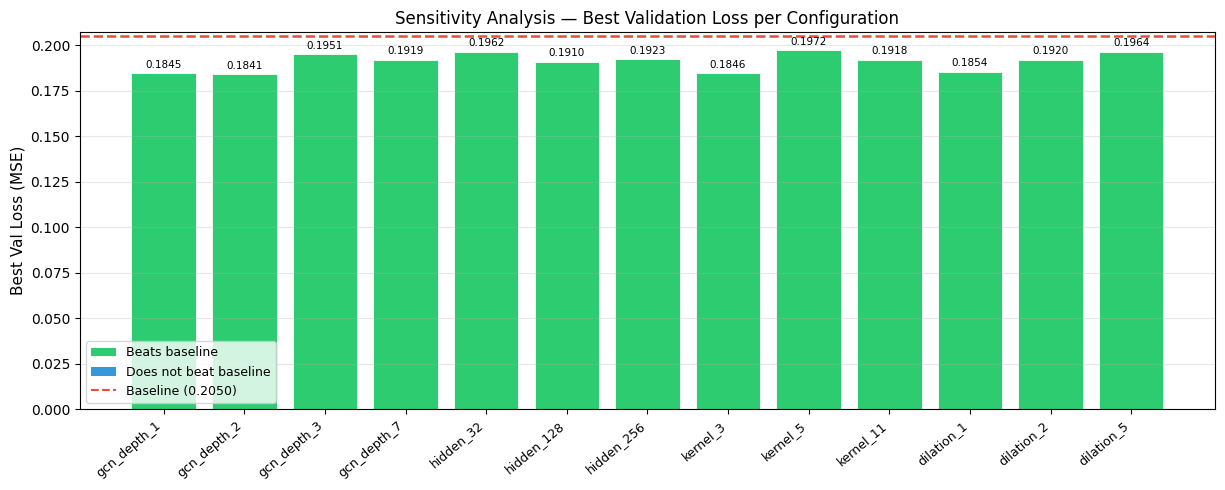

  📊 Saved: summary_val_loss_bar.png


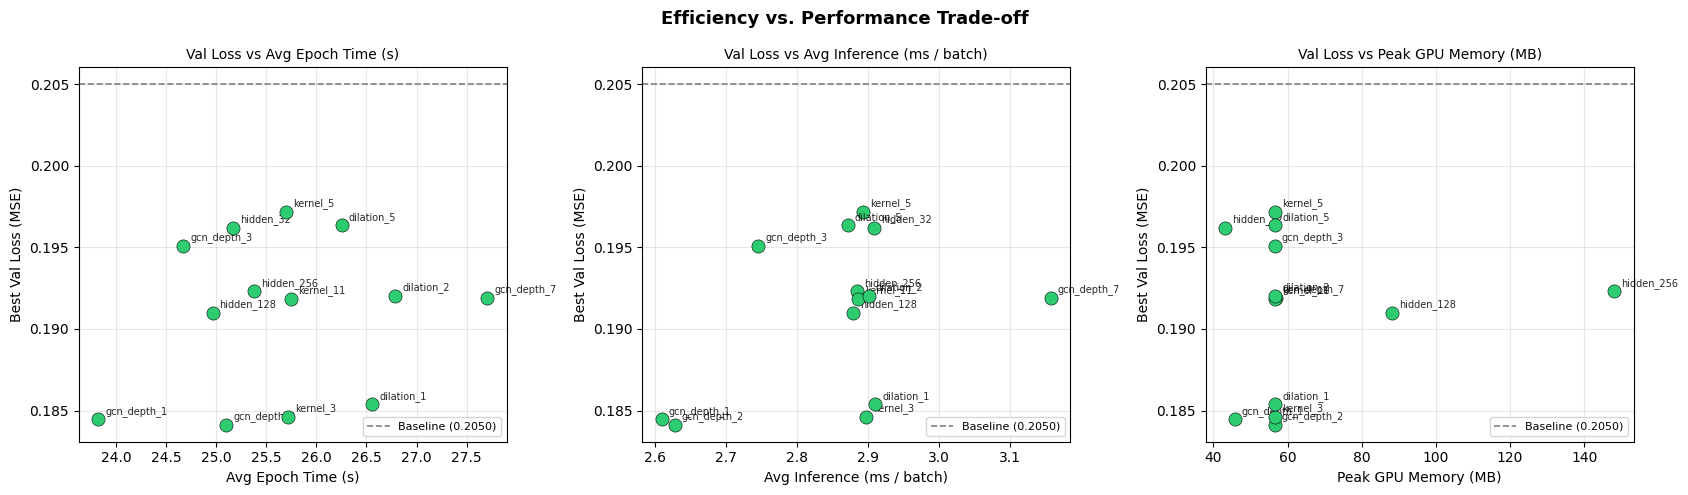

  📈 Saved: efficiency_scatter.png

✅ All outputs written to:  Sensitivity_Analysis/
   📊  Excel  : sensitivity_analysis_results.xlsx
   📈  Figures: loss_curves/  (6 PNGs)

🏆 13 config(s) beat the baseline — models saved for XAI reuse:
   • gcn_depth_1          | Val 0.1845 | Sensitivity_Analysis\gcn_depth_1_best_model.pth
   • gcn_depth_2          | Val 0.1841 | Sensitivity_Analysis\gcn_depth_2_best_model.pth
   • gcn_depth_3          | Val 0.1951 | Sensitivity_Analysis\gcn_depth_3_best_model.pth
   • gcn_depth_7          | Val 0.1919 | Sensitivity_Analysis\gcn_depth_7_best_model.pth
   • hidden_32            | Val 0.1962 | Sensitivity_Analysis\hidden_32_best_model.pth
   • hidden_128           | Val 0.1910 | Sensitivity_Analysis\hidden_128_best_model.pth
   • hidden_256           | Val 0.1923 | Sensitivity_Analysis\hidden_256_best_model.pth
   • kernel_3             | Val 0.1846 | Sensitivity_Analysis\kernel_3_best_model.pth
   • kernel_5             | Val 0.1972 | Sensitivity_Analysi

In [31]:
# ============================================================
# SENSITIVITY — Bar Plot, Scatter Plots & Final Summary
# ============================================================
ok_items = [(k, v) for k, v in all_results.items() if v.get("status") == "OK"]

# ── 1. Summary Bar: Best Val Loss ──
if ok_items:
    names      = [k for k, _ in ok_items]
    val_losses = [v["best_val_loss"] for _, v in ok_items]
    bar_colors = ["#2ecc71" if v["beats_baseline"] else "#3498db" for _, v in ok_items]

    fig, ax = plt.subplots(figsize=(max(12, len(names) * 0.95), 5))
    bars = ax.bar(names, val_losses, color=bar_colors, edgecolor="white", linewidth=0.6)
    if BASELINE_VAL_LOSS < float("inf"):
        ax.axhline(BASELINE_VAL_LOSS, color="#e74c3c", linestyle="--",
                   linewidth=1.8, label=f"Baseline ({BASELINE_VAL_LOSS:.4f})")
    ax.set_ylabel("Best Val Loss (MSE)", fontsize=11)
    ax.set_title("Sensitivity Analysis — Best Validation Loss per Configuration", fontsize=12)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=40, ha="right", fontsize=9)
    ax.grid(True, axis="y", alpha=0.3)

    for bar, loss in zip(bars, val_losses):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f"{loss:.4f}", ha="center", va="bottom", fontsize=7.5)

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor="#2ecc71", label="Beats baseline"),
        Patch(facecolor="#3498db", label="Does not beat baseline"),
        plt.Line2D([0],[0], color="#e74c3c", linestyle="--", label=f"Baseline ({BASELINE_VAL_LOSS:.4f})"),
    ], fontsize=9)

    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, "summary_val_loss_bar.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("  📊 Saved: summary_val_loss_bar.png")

# ── 2. Efficiency Scatter: Val Loss vs Time/Mem ──
if ok_items:
    metrics_to_plot = [
        ("avg_epoch_time_s", "Avg Epoch Time (s)"),
        ("avg_inference_ms", "Avg Inference (ms / batch)"),
        ("peak_gpu_mem_mb",  "Peak GPU Memory (MB)"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle("Efficiency vs. Performance Trade-off", fontsize=13, fontweight="bold")

    for ax, (metric_key, xlabel) in zip(axes, metrics_to_plot):
        for cfg_name, r in ok_items:
            x = r.get(metric_key)
            y = r.get("best_val_loss")
            if x is None or y is None: continue
            color = "#2ecc71" if r["beats_baseline"] else "#e74c3c"
            ax.scatter(x, y, color=color, s=90, zorder=3, edgecolors="black", linewidth=0.4)
            ax.annotate(cfg_name, (x, y), textcoords="offset points",
                        xytext=(5, 4), fontsize=7, alpha=0.85)

        if BASELINE_VAL_LOSS < float("inf"):
            ax.axhline(BASELINE_VAL_LOSS, color="gray", linestyle="--",
                       linewidth=1.2, label=f"Baseline ({BASELINE_VAL_LOSS:.4f})")
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel("Best Val Loss (MSE)", fontsize=10)
        ax.set_title(f"Val Loss vs {xlabel}", fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, "efficiency_scatter.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("  📈 Saved: efficiency_scatter.png")

# ── 3. Final Console Summary ──
print(f"\n{'='*64}")
print(f"✅ All outputs written to:  {SAVE_DIR}/")
print(f"   📊  Excel  : sensitivity_analysis_results.xlsx")
print(f"   📈  Figures: loss_curves/  ({4 + 2} PNGs)")
print(f"{'='*64}")

winners = [(k, v) for k, v in all_results.items() if v.get("beats_baseline")]
if winners:
    print(f"\n🏆 {len(winners)} config(s) beat the baseline — models saved for XAI reuse:")
    for k, v in winners:
        print(f"   • {k:20s} | Val {v['best_val_loss']:.4f} | {v['model_path']}")
else:
    print("\n  No config beat the baseline this run.")